# Supply-side and unlock-event analysis (tokenomist)

**Companion to `01_pilot_walkthrough.ipynb`.** Notebook 1 covers the price-side analysis (Findings 1-3 in the README, fig1 and fig2). This notebook covers the supply-side analysis using tokenomist's API.

What this notebook does:

1. Pulls the full token list from tokenomist via the API. Free trial returns 50 tokens; paid tiers return all ~410.
2. Computes a supply-side breakdown: locked vs. unlocked vs. untracked share for each covered token.
3. Intersects with the CoinGecko universe used in notebook 1.
4. Pulls historical unlock events for the intersection.
5. Produces three supplementary figures: (3) the unlock-event calendar, (4) cross-sectional locked-share distribution, (5) cumulative dilution over the lookback window — the supply-side parallel to the price-side mismeasurement findings in notebook 1.

**Sample size note.** With the free-trial 50-token cap and the resulting small intersection with the CoinGecko universe, the sample here is too small for predictive tests. The figures are descriptive and intended to (i) show that the supply-side data infrastructure is in place and (ii) demonstrate the magnitude of supply pressure individual tokens have absorbed. The full project will use a paid Standard tier for full coverage.

## Setup

In [1]:
import os
from pathlib import Path

env_path = Path('..') / '.env'
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        k, v = line.split('=', 1)
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

key = os.environ.get('TOKENOMIST_API_KEY', '').strip()
if not key:
    raise RuntimeError('TOKENOMIST_API_KEY not found. Add it to .env and re-run.')
print(f'tokenomist key loaded: {key[:5]}...{key[-3:]}')

tokenomist key loaded: 70556...05c


In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from IPython.display import Image

from src import tokenomist, plots

# We need the CoinGecko symbol universe to compute the intersection. Load from
# the panel.csv that notebook 1 produces. Run notebook 1 first if this file
# does not exist.
panel = pd.read_csv('../data/panel.csv')
cg_symbols = {s.upper() for s in panel['symbol'].dropna()}
print(f'CoinGecko universe (from notebook 1): {len(cg_symbols)} tokens')

CoinGecko universe (from notebook 1): 90 tokens


## 1. Token list and tier detection

In [3]:
tokens_df = tokenomist.list_tokens()
print(f'tokenomist coverage: {len(tokens_df)} tokens ({tokenomist.detect_tier(tokens_df)})')
tokens_df.head()

tokenomist coverage: 49 tokens (likely free trial (49 tokens; trial cap is 50))


,id,name,symbol,listedMethod,circulatingSupply,marketCap,maxSupply,totalLockedAmount,tbdLockedAmount,unlockedAmount,untrackedAmount,hasStandardAllocation,hasFundraising,latestFundraisingRound,hasBurn,hasBuyback,websiteUrl,lastUpdatedDate
0,aave,Aave,AAVE,INTERNAL,1.517570e+07,1427824275,1.600000e+07,6.196469e+05,0.000000e+00,1.538035e+07,0.0,True,True,Undisclosed,False,True,https://tokenomist.ai/aave,2025-02-17T02:50:55Z
1,algorand,Algorand,ALGO,INTERNAL,8.904793e+09,918011819,1.000000e+10,0.000000e+00,0.000000e+00,1.000000e+10,0.0,True,True,Public Token Sale,False,False,https://tokenomist.ai/algorand,2025-02-17T02:45:18Z
2,aptos,Aptos,APT,INTERNAL,8.066021e+08,763048728,2.100000e+09,1.481932e+09,0.000000e+00,1.675834e+09,0.0,True,True,Strategic Round,True,False,https://tokenomist.ai/aptos,2025-12-01T12:48:21Z
3,arbitrum,Arbitrum,ARB,INTERNAL,6.040824e+09,778564125,1.000000e+10,1.191307e+09,3.403750e+09,5.404943e+09,0.0,True,True,Series B,False,False,https://tokenomist.ai/arbitrum,2025-06-11T10:31:15Z
4,avalanche-2,Avalanche,AVAX,INTERNAL,4.317720e+08,4035415411,7.200000e+08,1.848943e+08,0.000000e+00,5.351057e+08,0.0,True,True,Strategic Round,True,False,https://tokenomist.ai/avalanche-2,2025-02-05T03:53:29Z


## 2. Supply-side breakdown

Locked / unlocked / untracked amounts per token from tokenomist's own labels. The `locked_share_of_trackable` column is the supply-side overhang measure summarized in `fig4_locked_share.png` below.

In [4]:
supply_df = tokenomist.supply_breakdown(tokens_df)
supply_df.to_csv('../data/tokenomist_supply.csv', index=False)
supply_df.sort_values('locked_share_of_trackable', ascending=False).head(15)

,id,symbol,name,circulatingSupply,marketCap,maxSupply,totalLockedAmount,tbdLockedAmount,unlockedAmount,untrackedAmount,locked_share_of_trackable,untracked_share_of_total
36,raydium,RAY,Raydium,2.687180e+08,178824910,5.550000e+08,0.000000e+00,4.107000e+08,1.443000e+08,0.000000e+00,0.740000,0.000000e+00
27,movement,MOVE,Movement,3.672917e+09,68124302,1.000000e+10,6.491667e+09,0.000000e+00,3.508333e+09,0.000000e+00,0.649167,0.000000e+00
41,sui,SUI,Sui,3.953389e+09,3737297065,1.000000e+10,8.274045e+08,5.217207e+09,3.955389e+09,0.000000e+00,0.604461,0.000000e+00
19,hyperliquid,HYPE,Hyperliquid,2.383853e+08,9813017888,1.000000e+09,1.858755e+08,3.888800e+08,4.252445e+08,0.000000e+00,0.574756,0.000000e+00
18,filecoin,FIL,Filecoin,7.730060e+08,717688395,2.000000e+09,7.620764e+08,3.000000e+08,9.379236e+08,0.000000e+00,0.531038,0.000000e+00
31,optimism,OP,Optimism,2.150100e+09,260543084,4.294967e+09,1.521860e+08,2.089717e+09,2.053065e+09,8.000007e-01,0.521984,1.862647e-10
47,worldcoin-wld,WLD,Worldcoin,3.290998e+09,867873387,1.000000e+10,4.936813e+09,0.000000e+00,5.063187e+09,0.000000e+00,0.493681,0.000000e+00
25,mantle,MNT,Mantle,3.277944e+09,2112423124,6.219317e+09,0.000000e+00,3.046329e+09,3.172988e+09,2.689000e+01,0.489817,4.323626e-09
22,jupiter-exchange-solana,JUP,Jupiter,3.550836e+09,610557178,7.000000e+09,7.347222e+08,2.632700e+09,3.632578e+09,0.000000e+00,0.481060,0.000000e+00
2,aptos,APT,Aptos,8.066021e+08,763048728,2.100000e+09,1.481932e+09,0.000000e+00,1.675834e+09,0.000000e+00,0.469298,0.000000e+00


## 3. Intersection with CoinGecko universe

In [5]:
matched = tokens_df[tokens_df['symbol'].str.upper().isin(cg_symbols)]
print(f'intersection: {len(matched)} tokens covered by both CoinGecko and tokenomist')
matched[['id', 'symbol', 'name', 'circulatingSupply', 'totalLockedAmount', 'unlockedAmount']].head(15)

intersection: 15 tokens covered by both CoinGecko and tokenomist


,id,symbol,name,circulatingSupply,totalLockedAmount,unlockedAmount
0,aave,AAVE,Aave,1.517570e+07,6.196469e+05,1.538035e+07
3,arbitrum,ARB,Arbitrum,6.040824e+09,1.191307e+09,5.404943e+09
6,bittensor,TAO,Bittensor,9.597491e+06,9.010002e+06,1.133375e+07
10,chainlink,LINK,Chainlink,7.271000e+08,0.000000e+00,5.881000e+08
14,ethena,ENA,Ethena,8.759375e+09,4.928125e+09,8.048438e+09
17,fetch-ai,FET,Artificial Superintelligence Alliance,2.258796e+09,3.414994e+08,2.184257e+09
20,immutable-x,IMX,Immutable,8.424446e+08,0.000000e+00,2.000000e+09
21,injective-protocol,INJ,Injective,1.000000e+08,0.000000e+00,1.000000e+08
24,lido-dao,LDO,Lido DAO,8.491902e+08,1.192093e-07,1.000000e+09
31,optimism,OP,Optimism,2.150100e+09,1.521860e+08,2.053065e+09


## 4. Historical unlock events for the intersection

In [6]:
events_df = tokenomist.fetch_all_unlock_events(matched['id'].tolist())
events_df.to_csv('../data/tokenomist_unlock_events.csv', index=False)
print(f'fetched {len(events_df)} (event, allocation) rows across {events_df["tokenSymbol"].nunique()} tokens')
events_df.head(10)

[  1/15] tokenomist unlocks: aave
[  2/15] tokenomist unlocks: arbitrum
[  3/15] tokenomist unlocks: bittensor
[  4/15] tokenomist unlocks: chainlink
[  5/15] tokenomist unlocks: ethena
[  6/15] tokenomist unlocks: fetch-ai
[  7/15] tokenomist unlocks: immutable-x
[  8/15] tokenomist unlocks: injective-protocol
[  9/15] tokenomist unlocks: lido-dao
[ 10/15] tokenomist unlocks: optimism
[ 11/15] tokenomist unlocks: pepe
[ 12/15] tokenomist unlocks: shiba-inu
[ 13/15] tokenomist unlocks: the-graph
[ 14/15] tokenomist unlocks: uniswap
[ 15/15] tokenomist unlocks: worldcoin-wld
fetched 104 (event, allocation) rows across 4 tokens


,tokenId,tokenSymbol,tokenName,unlockDate,allocationName,standardAllocationName,cliffAmount,cliffValue,valueToMarketCap,referencePrice,unlockPrecision
0,arbitrum,ARB,Arbitrum,2025-05-16 13:00:00,Investors,Private Investors,36520833.4,1.447467e+07,4.716278,0.396340,day
1,arbitrum,ARB,Arbitrum,2025-05-16 13:00:00,"Team, Future Team + Advisors",Founder / Team,56125000.0,2.224458e+07,4.716278,0.396340,day
2,arbitrum,ARB,Arbitrum,2025-06-16 13:00:00,Investors,Private Investors,36520833.3,1.196390e+07,3.898194,0.327591,day
3,arbitrum,ARB,Arbitrum,2025-06-16 13:00:00,"Team, Future Team + Advisors",Founder / Team,56125000.0,1.838604e+07,3.898194,0.327591,day
4,arbitrum,ARB,Arbitrum,2025-07-16 13:00:00,Investors,Private Investors,36520833.0,1.589898e+07,5.180362,0.435340,day
5,arbitrum,ARB,Arbitrum,2025-07-16 13:00:00,"Team, Future Team + Advisors",Founder / Team,56125000.0,2.443346e+07,5.180362,0.435340,day
6,arbitrum,ARB,Arbitrum,2025-08-16 13:00:00,Investors,Private Investors,36520834.0,1.759311e+07,5.732359,0.481728,day
7,arbitrum,ARB,Arbitrum,2025-08-16 13:00:00,"Team, Future Team + Advisors",Founder / Team,56125000.0,2.703698e+07,5.732359,0.481728,day
8,arbitrum,ARB,Arbitrum,2025-09-16 13:00:00,"Team, Future Team + Advisors",Founder / Team,56125000.0,2.761737e+07,5.855413,0.492069,day
9,arbitrum,ARB,Arbitrum,2025-09-16 13:00:00,Investors,Private Investors,36520833.0,1.797077e+07,5.855413,0.492069,day


## 5. Supplementary figures

  wrote ../figures/fig3_unlock_calendar.png


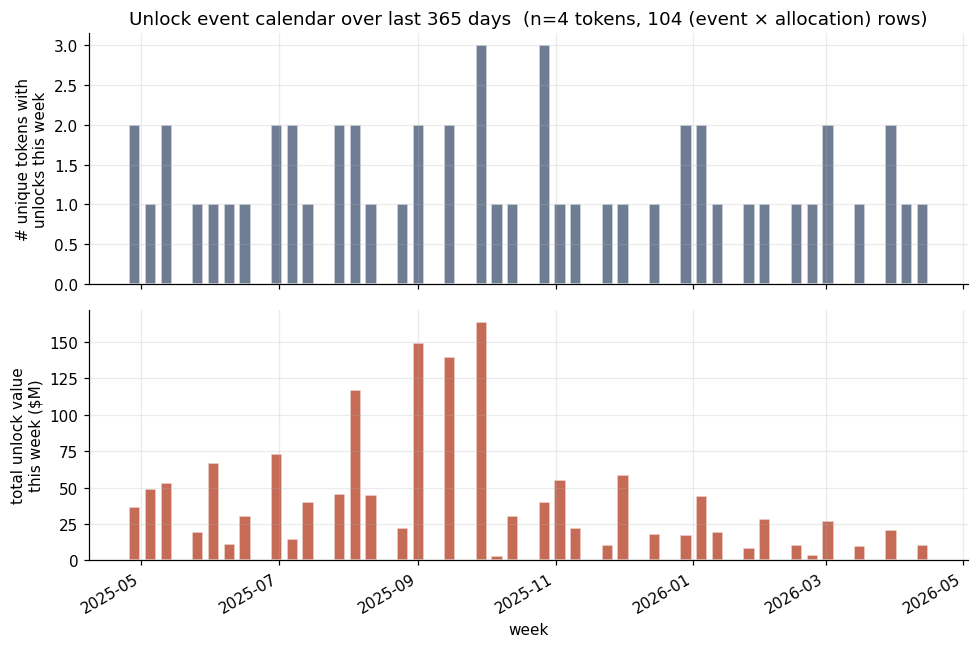

In [7]:
plots.fig3_unlock_calendar(events_df, '../figures/fig3_unlock_calendar.png')
Image('../figures/fig3_unlock_calendar.png')

  wrote ../figures/fig4_locked_share.png


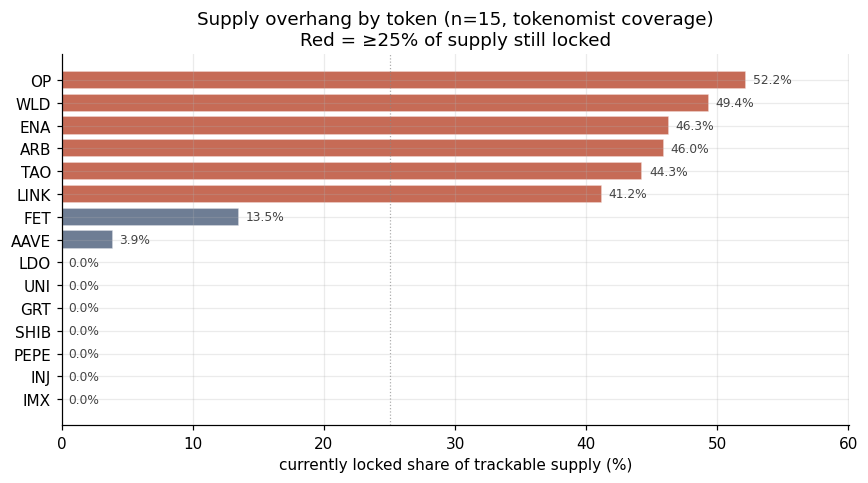

In [8]:
matched_supply = supply_df[supply_df['symbol'].str.upper().isin(cg_symbols)]
plots.fig4_locked_share(matched_supply, '../figures/fig4_locked_share.png')
Image('../figures/fig4_locked_share.png')

## 6. Cumulative dilution over the lookback window

For each token, sum tokenomist's per-event `valueToMarketCap` across all unlock events in the past 365 days. This is a units-friendly approximation of *how much supply, valued in market-cap-equivalent terms, has flooded the float over the period*. Values close to or above 100% indicate that cumulative released supply over the period was worth roughly the same as the token's market capitalization — i.e., the float roughly doubled in market-cap terms.

Caveat: the denominator (mcap) varies across events, so this is a magnitude rather than a strict ratio. Read it as an order-of-magnitude indicator of supply pressure, not as a precise dilution percentage.

In [9]:
dilution = tokenomist.cumulative_dilution(events_df, lookback_days=365)
dilution.to_csv('../data/tokenomist_cumulative_dilution.csv', index=False)
dilution

,tokenSymbol,cumulative_dilution_pct,cliff_value_total_usd,n_events
0,OP,106.913498,2.785557e+08,18
1,ENA,88.171467,8.237380e+08,24
2,IMX,63.257364,9.529704e+07,7
3,ARB,40.952154,3.188388e+08,12


  wrote ../figures/fig5_cumulative_dilution.png


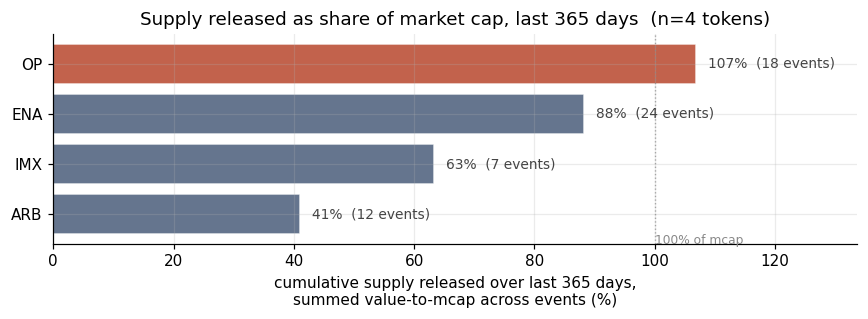

In [10]:
plots.fig5_cumulative_dilution(dilution, '../figures/fig5_cumulative_dilution.png')
Image('../figures/fig5_cumulative_dilution.png')

## What this notebook shows

- **Locked-share spread (fig4):** the supply-side overhang varies widely across covered tokens, with several at >40% of trackable supply still locked. This cross-sectional spread is what makes an unlock event-study identifiable in principle.
- **Cumulative dilution (fig5):** in the four-token intersection sample, three of four tokens absorbed cumulative supply releases worth more than 40% of their market cap over the past year, with OP exceeding 100%. This is the supply-side parallel to the price-side mismeasurement: even setting aside questions of liquidity, reported market cap can mask large recurring float expansions.
- **Unlock-event coverage (fig3):** the pipeline can pull, parse, and align scheduled unlock events with the CoinGecko price/volume series at the symbol level. The full project will scale this up using paid-tier API access and run the actual event-study regressions on realized post-event returns.